# `symmscreen`: molecular-crystal symmetry screening

This notebook demonstrates how to use `symmscreen` to estimate how much daily-modulation anisotropy is retained by molecular crystals.

The package implements the symmetry-projection estimators described in the accompanying manuscript. In that convention, every reported $\Lambda$ value is a **survival / retained-modulation estimator**. Larger is better. The entries below are shown as percentages of the ideal directional modulation retained by the symmetry screen.

The notebook covers:

1. Installing and importing `symmscreen`.
2. Interpreting the main survival metrics.
3. A simple worked example of the estimators.
4. Orientation-specific survival scans.
5. A naive, label-only ranking of molecule/crystal point-group combinations.
6. Computing the survival fraction for a real CIF.
7. Visualising the unit cell.
8. Looking at the projector matrices themselves.

These numbers are **screening proxies**, not full scattering-rate calculations. They do not include electronic transition matrix elements, finite momentum transfer form factors, mediator dependence, detector response, or the dark-matter velocity distribution.

## 1. Install and import

In [4]:
# Install the released package from PyPI.
%pip -q install --upgrade symmscreen

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import importlib.metadata as md
from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import symmscreen as ss
from symmscreen import CombinedSurvival

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)

print("Python:", sys.version.split()[0])
print("symmscreen version:", md.version("symmscreen"))
print("symmscreen module:", ss.__file__)

Python: 3.13.13
symmscreen version: 0.1.2
symmscreen module: /home/jack-shergold/Documents/Work/Projects/molecules/symmetry_sweep/package/src/symmscreen/__init__.py


In [ ]:
import shutil

# Prefer real LaTeX rendering for plot text when a TeX install is available;
# otherwise fall back to Matplotlib's built-in "cm" mathtext, which mimics
# Computer Modern without needing LaTeX at all.
usetex = shutil.which("latex") is not None
plt.rcParams.update({
    "text.usetex": usetex,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#cfcfcf",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.8,
})
if usetex:
    plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath,amssymb}"

print("Using LaTeX for plot text:", usetex)

## 2. Survival metrics

The package has several related survival estimators. They answer different questions. In this notebook, $\Lambda$ always denotes the **retained modulation signal fraction** or **survival**, reported as a percentage. Larger values mean that less modulation signal is lost to symmetry-induced averaging of the directional signal.

All functions below are plain top-level calls (`lambda_L_avg`, `lambda_ideal_avg`, `lambda_coord`) -- none of them require building a `CombinedSurvival` object yourself. That's only needed if you want more than one metric at once, or want to inspect the underlying projector matrices.

| Symbol | Function | What it means | When to use it |
|---|---|---|---|
| $\langle \Lambda^{(\mathcal{L})} \rangle_\mathcal{T}$ | `lambda_L_avg(mol_pg_symbol, crys_pg_symbol)` | Modulation-loss estimator for crystallisation alone (relative to the same molecule uncrystallised), analytically averaged over the unknown relative molecule/crystal orientation $\mathcal{T}$. | When you know the molecule and crystal point groups but not the relative orientation, e.g. before a crystal structure has been determined. Setting `mol_pg_symbol="C1"` is also the right choice for non-molecular crystals (e.g. purely atomic/ionic ones), where there is no molecular point group at all. |
| $\langle \Lambda \rangle_\mathcal{T}$ | `lambda_ideal_avg(mol_pg_symbol, crys_pg_symbol)` | Absolute modulation-loss estimator (relative to a hypothetical molecule with no internal symmetry), analytically averaged over $\mathcal{T}$. | Comparing different candidate molecular crystals when the exact embedding of the molecules are unknown. |
| $\Lambda_\mathrm{coord}$ | `lambda_coord(cif_path)` | Coordinate-aware estimator using the molecule's principal-axis shape; tracks the true $f_\mathrm{RMS}$ ratio in the paper's benchmarks. | Headline number whenever a CIF (or other real coordinates) is available. |

Note: for any non-cubic crystal and molecule, both averaged estimators reduce to good approximations in terms of just the crystal's and molecule's quadrupole survival classes, $\mathsf{Q}_k$, with $k_\mathrm{crys}, k_\mathrm{mol} \in \{0,1,2,3,5\}$ (see the paper's conclusions, Fig. 12):

$$\langle \Lambda^{(\mathcal{L})} \rangle_\mathcal{T} \approx \sqrt{k_\mathrm{crys}/5}, \qquad \langle \Lambda \rangle_\mathcal{T} \approx \sqrt{k_\mathrm{crys}\, k_\mathrm{mol}}/5.$$

So both can equally well be estimated directly from `quadrupole_class(pg_symbol=...)`, called once on the crystal's point group and once on the molecule's, without running the full $\langle \Lambda^{(\mathcal{L})} \rangle_\mathcal{T}$ / $\langle \Lambda \rangle_\mathcal{T}$ calculation at all.

## 3. Benzene example: $D_{6h}$ molecule in a $D_{2h}$ crystal

A quick illustration of what the estimators do and how to call them. A benzene molecule has internal point group symmetry $H = D_{6h}$, and its most common crystal polymorph has $P(S) = D_{2h}$ point group symmetry. Without knowing the exact embedding, we can still estimate how much of the modulation signal is lost to the crystal symmetry using the `lambda_L_avg` estimator, and its absolute modulation signal loss relative to the perfect molecular crystal using `lambda_ideal_avg`.

In [2]:
mol_pg = "D6h"
crys_pg = "D2h"

print(f"<Lambda^(L)>_T = {ss.lambda_L_avg(mol_pg_symbol=mol_pg, crys_pg_symbol=crys_pg):.3f},")
print(f"<Lambda>_T = {ss.lambda_ideal_avg(mol_pg_symbol=mol_pg, crys_pg_symbol=crys_pg):.3f}.")

<Lambda^(L)>_T = 0.632,
<Lambda>_T = 0.283.


This agrees with the estimates from the quadrupole survival classes: $D_{6h} \in \mathsf{Q}_1$, $D_{2h} \in \mathsf{Q}_2$.

In [ ]:
k_mol = ss.quadrupole_class(mol_pg)
k_crys = ss.quadrupole_class(crys_pg)

print(f"Simpler estimate from quadrupole class alone:")
print(f"<Lambda^(L)>_T ~ sqrt(k_crys/5) = {np.sqrt(k_crys/5):.3f}",)
print(f"<Lambda>_T ~ sqrt(k_crys*k_mol)/5 = {np.sqrt(k_crys*k_mol)/5:.3f}")

## 4. Orientation-specific survival scan

Sometimes it may be interesting to see how the survival fraction $\Lambda^{(\mathcal{L})}(T)$ changes as the relative orientation, $\mathcal{T}$, between the molecule and the crystal symmetries changes.

First, we rotate the molecule 360 degrees about one generic axis.

In [ ]:
from scipy.spatial.transform import Rotation

orientation_mol_pg = "D6h"
orientation_crys_pg = "D2h"

angles = np.linspace(0.0, 360.0, 145)

# Rotate about a generic axis rather than a high-symmetry one, which can look misleadingly flat.
axis = np.array([1.0, 1.0, 0.35])
axis = axis / np.linalg.norm(axis)

orientation_survival = np.zeros_like(angles)
for i, angle in enumerate(angles):
    T = Rotation.from_rotvec(np.deg2rad(angle) * axis).as_matrix()
    Cl = CombinedSurvival.from_symmetry(
        mol_pg_symbol=orientation_mol_pg,
        crys_pg_symbol=orientation_crys_pg,
        T=T,
    )
    orientation_survival[i] = 100.0 * Cl.lambda_L()

print("First few survival values [%]:", np.round(orientation_survival[:5], 3))

Now plot the results.

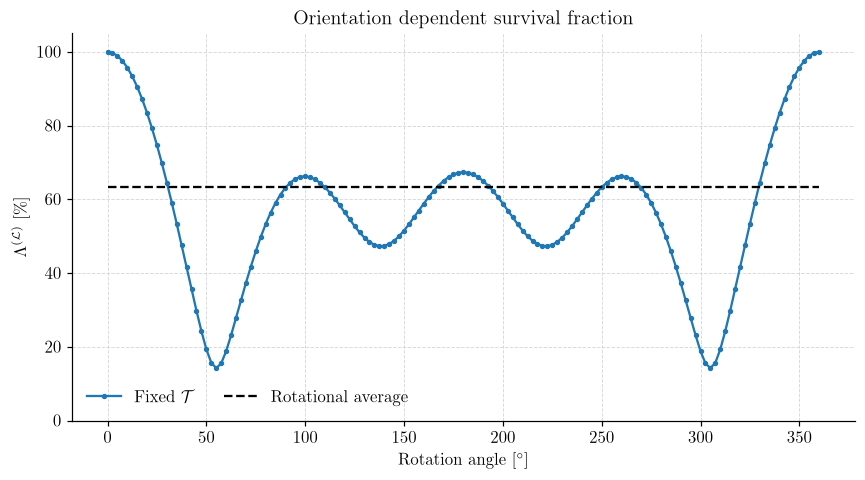

In [37]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    angles,
    orientation_survival,
    marker="o",
    markersize=2.5,
    color="C0",
    label=r"Fixed $\mathcal{T}$"
)
# Also plot the rotational average.
ax.hlines(ss.lambda_L_avg(mol_pg_symbol=orientation_mol_pg, crys_pg_symbol=orientation_crys_pg)*100,0,360, color="k", linestyle="--", label=r"Rotational average")

ax.set_xlabel(r"Rotation angle [$^\circ$]")
ax.set_ylabel(r"$\Lambda^{(\mathcal{L})}$ [\%]")
ax.set_title(r"Orientation dependent survival fraction")
ax.set_ylim(0, 105)
ax.legend(frameon=False, ncol=2)
ax.ticklabel_format(useOffset=False, axis="y")

plt.tight_layout()
plt.show()

Now, scan *every* possible molecular axis direction, holding the crystal symmetry axis fixed along $\hat z$.

In [ ]:
from symmscreen import CrystalProjector, MoleculeProjector

# Build the projectors once and reuse them.
sphere_crystal = CrystalProjector(pg_symbol=orientation_crys_pg)
sphere_molecule = MoleculeProjector(pg_symbol=orientation_mol_pg)


def rotate_molecule(theta, phi):
    """Rotation taking the molecule's own z-axis to the direction (theta, phi)."""
    direction = np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta),
    ])
    axis = np.cross([0.0, 0.0, 1.0], direction)
    axis_norm = np.linalg.norm(axis)
    # If the direction is along the z-axis, return the identity or a 180-degree rotation about x.
    if axis_norm < 1e-10:
        if direction[2] > 0:
            return np.eye(3)
        return Rotation.from_rotvec(np.pi * np.array([1.0, 0.0, 0.0])).as_matrix()
    angle = np.arccos(np.clip(direction[2], -1.0, 1.0))
    return Rotation.from_rotvec(angle * axis / axis_norm).as_matrix()


n_theta, n_phi = 51, 101
thetas = np.linspace(0.0, np.pi, n_theta)
phis = np.linspace(0.0, 2 * np.pi, n_phi)

sphere_survival = np.zeros((n_theta, n_phi))
for i, theta in enumerate(thetas):
    for j, phi in enumerate(phis):
        Cl = CombinedSurvival(sphere_crystal, sphere_molecule, T=rotate_molecule(theta, phi))
        sphere_survival[i, j] = 100.0 * Cl.lambda_L()

print(
    "Survival range over all molecule-axis directions: "
    f"{sphere_survival.min():.1f}% to {sphere_survival.max():.1f}%"
)

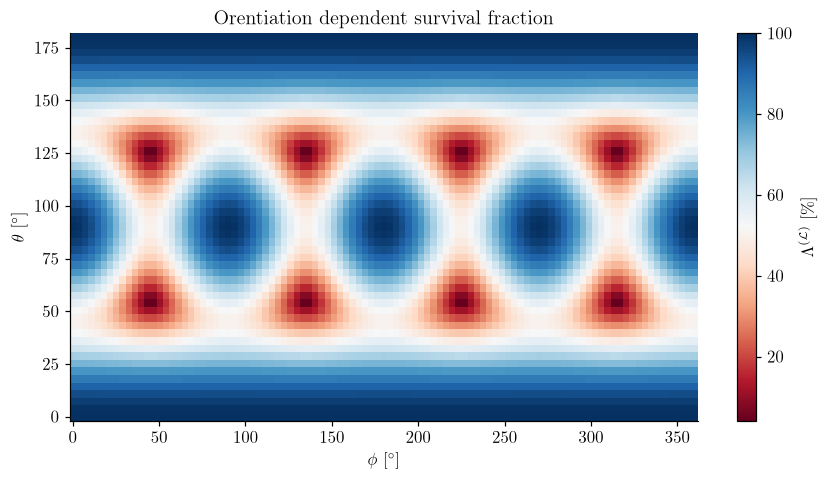

In [48]:
plt.figure(figsize=(8, 4.5))

image = plt.pcolormesh(
    np.rad2deg(phis),
    np.rad2deg(thetas),
    sphere_survival,
    shading="auto",
    cmap="RdBu",
)

plt.xlabel(r"$\phi$ [$^\circ$]")
plt.ylabel(r"$\theta$ [$^\circ$]")
plt.title(r"Orentiation dependent survival fraction")
plt.colorbar(image, label=r"$\Lambda^{(\mathcal{L})}$ [$\%$]")
plt.tight_layout()
plt.show()

## 5. A naive estimate of the best combinations

With no orientation or coordinates at all, `lambda_ideal_avg` gives a quick, point-group-only ranking of candidate molecule-crystal point group pairs, using just their quadrupole classes $\mathsf{Q}_k$. Larger $\langle \Lambda \rangle_\mathcal{T}$ is better.

In [ ]:
molecule_groups = ["C1", "Ci", "C2", "C2v", "D2h", "D4h", "D6h", "Oh"]
crystal_groups = ["C1", "C2h", "C2v", "D2h", "D4h", "Oh"]

rows = []
for mpg in molecule_groups:
    for cpg in crystal_groups:
        s = CombinedSurvival.from_symmetry(mol_pg_symbol=mpg, crys_pg_symbol=cpg)
        rows.append({
            "molecule_pg": mpg,
            "crystal_pg": cpg,
            "molecule_Q": s.molecule.quadrupole_class,
            "crystal_Q": s.crystal.quadrupole_class,
            "ideal_avg_%": 100.0 * s.lambda_ideal_avg(),
        })

pd.DataFrame(rows).sort_values("ideal_avg_%", ascending=False).reset_index(drop=True)

## 6. Survival for a real CIF

This downloads an open benzene CIF from the Crystallography Open Database: [COD 2100349](https://www.crystallography.net/cod/2100349.html). This is benzene's ambient-pressure polymorph, with space group $Pbca$, corresponding to point group $D_{2h}$. Since we'll want more than one metric from it below (Sections 7-8), we build a `CombinedSurvival` object directly rather than using the one-line `lambda_coord` function.

In [ ]:
# COD 2100349: benzene, orthorhombic Pbca.
cif_url = "https://www.crystallography.net/cod/2100349.cif"
cif_path = Path("benzene_2100349.cif")
urllib.request.urlretrieve(cif_url, cif_path)

print("Downloaded CIF:", cif_path, f"({cif_path.stat().st_size} bytes)")

In [ ]:
cif_survival = CombinedSurvival.from_cif(cif_path)
survival = cif_survival.lambda_coord()

print("Survival fraction for COD 2100349:", f"{100.0 * survival:.3f}%.")

## 7. Visualise the unit cell

`CombinedSurvival.plot()` draws every molecule in the unit cell plus the cell edges, using the atoms `symmscreen` already extracted from the CIF.

In [ ]:
cif_survival.plot()

## 8. Look at the projectors

For this same CIF, here are the actual $l=2$ and $l=4$ projector matrices in the real spherical-harmonic basis: the crystal projector $\Pi^{(L)}$, the molecule projector $\Pi^{(H)}$, and the combined survival operator $C^{(l)} = \Pi^{(L)} \Pi^{(H)}$.

In [18]:
np.set_printoptions(precision=2, suppress=True)

print("==== l=2 projector matrices ====")

print("Crystal projector Pi^(L):")
print(cif_survival.crystal.matrix(l=2))

print("\nMolecule projector Pi^(H):")
print(cif_survival.molecule.matrix(l=2))

print("\nCombined survival operator C^(l):")
print(cif_survival.matrix(l=2))

print("\n==== l=4 projector matrices ====")

print("Crystal projector Pi^(L):")
print(cif_survival.crystal.matrix(l=4))

print("\nMolecule projector Pi^(H):")
print(cif_survival.molecule.matrix(l=4))

print("\nCombined survival operator C^(l):")
print(cif_survival.matrix(l=4))

==== l=2 projector matrices ====
Crystal projector Pi^(L):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]

Molecule projector Pi^(H):
[[ 0.08 -0.08  0.06 -0.23  0.1 ]
 [-0.08  0.08 -0.06  0.23 -0.1 ]
 [ 0.06 -0.06  0.04 -0.17  0.07]
 [-0.23  0.23 -0.17  0.67 -0.29]
 [ 0.1  -0.1   0.07 -0.29  0.13]]

Combined survival operator C^(l):
[[ 0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.  ]
 [ 0.06 -0.06  0.04 -0.17  0.07]
 [ 0.    0.    0.    0.    0.  ]
 [ 0.1  -0.1   0.07 -0.29  0.13]]

==== l=4 projector matrices ====
Crystal projector Pi^(L):
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]

Molecule projector Pi^(H):
[[ 0.04 -0.09  0.08 -0.01 -0.08 -0.02  0.11 -0.06  0.01]
 [-0.09  0.22 -0.2   0.02  0.2   0.05 -